In [1]:
import matplotlib.pyplot as plt
import math
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import random_split, DataLoader
from torchvision import datasets, transforms
from torchmetrics.classification import (MulticlassAccuracy,
                                         MulticlassPrecision,
                                         MulticlassRecall,
                                         MulticlassF1Score,
                                         MulticlassConfusionMatrix)
from sklearn.metrics import ConfusionMatrixDisplay


# Base Model

In [2]:
def display_images(dataset, num_images=9):
    cols = math.ceil((num_images) ** 0.5)
    rows = math.ceil(num_images / cols)

    plt.figure(figsize=(8, 8))

    for i in range(num_images):
        image, label = dataset[i]

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.title(f'Label: {label}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [3]:
def get_label_counts(dataset):
    label = [label for _, label in dataset]
    return pd.Series(label).value_counts().sort_index()

In [4]:
def visualize_split(train, validation, test):
    train_label_counts = get_label_counts(train)
    val_label_counts = get_label_counts(validation)
    test_label_counts = get_label_counts(test)

    counts_df = pd.DataFrame({
                            'Train': train_label_counts,
                            'Validation': val_label_counts,
                            'Test': test_label_counts})

    counts_df.plot(kind='bar', stacked=True, 
        color=['skyblue', 'lightgreen', 'lightcoral'], 
        edgecolor='black'
        )
    
    plt.title('Label Distribution')
    plt.xlabel('Digit')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [5]:
def validation_set(train_dataset, train_ratio=0.8, random_state=123):
    train_size = int(train_ratio * len(train_dataset))
    val_size = len(train_dataset) - train_size

    train_subset, val_subset = random_split(
        train_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(random_state)
    )
    return train_subset, val_subset

In [6]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [7]:
def train(model, train_loader, val_loader, criterion, optimizer, epochs=25):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0.0, 0

        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0) 

        train_loss /= train_total 
        train_acc = train_correct / train_total 

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0.0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Epoch: {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}')
        print(f'Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_acc:.4f}')

    return history 

In [8]:
def test(
        model, test_loader, accuracy_metric, 
        precision_metric, recall_metric, f1_metric, 
        confusion_matrix_metric
        ):
    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            accuracy_metric.update(preds, labels)
            precision_metric.update(preds, labels)
            recall_metric.update(preds, labels)
            f1_metric.update(preds, labels)
            confusion_matrix_metric.update(preds, labels)

    accuracy = accuracy_metric.compute()
    precision = precision_metric.compute()
    recall = recall_metric.compute()
    f1 = f1_metric.compute()
    confusion_matrix = confusion_matrix_metric.compute().cpu().numpy()

    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 score: {f1:.4f}')
    print(f'Confusion Matrix:\n{confusion_matrix}')
    return confusion_matrix

In [9]:
def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Loss plot
    axes[0].plot(
        epochs,
        history['train_loss'],
        color='blue',
        label='Train Loss'
    )
    axes[0].plot(
        epochs,
        history['val_loss'],
        color='red',
        label='Validation Loss'
    )

    axes[0].set_title('Model Loss (Cross-Entropy)')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Accuracy plot
    axes[1].plot(
        epochs,
        history['train_acc'],
        color='blue',
        label='Train Accuracy'
    )
    axes[1].plot(
        epochs,
        history['val_acc'],
        color='red',
        label='Validation Accuracy'
    )

    axes[1].set_title('Model Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

In [10]:
def plot_confusion_matrix(confusion_matrix):
    display_labels = list(range(10))
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=display_labels)
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.show()

In [11]:
def main(plot = True):
    train_dataset = datasets.MNIST(
        root='data', 
        train=True, 
        download=False, 
        transform=transforms.ToTensor())
    
    test_dataset = datasets.MNIST(
        root='data',
        train=False,
        download=False,
        transform=transforms.ToTensor())

    train_subset, validation_subset = validation_set(train_dataset, train_ratio=0.85)

    if plot:
        # Display example images of the dataset:
        display_images(train_dataset)

        # Dataset visualization plot:
        visualize_split(train_subset, validation_subset, test=test_dataset)

    # DataLoader:
    batch_size = 32
    train_loader = DataLoader(dataset=train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(dataset=validation_subset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

    model = CNN()

    # Training:
    num_epochs = 25
    lr = 0.001
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = train(model=model, train_loader = train_loader, 
                    val_loader = val_loader, 
                    criterion = criterion, optimizer = optimizer, 
                    epochs=num_epochs)

    if plot:
        plot_training_history(history)

    # Testing:
    accuracy_metric = MulticlassAccuracy(num_classes=10, average='micro')
    precision_metric = MulticlassPrecision(num_classes=10, average='macro')
    recall_metric = MulticlassRecall(num_classes=10, average='macro')
    f1_metric = MulticlassF1Score(num_classes=10, average='macro')
    confusion_matrix_metric = MulticlassConfusionMatrix(num_classes=10)

    confusion_matrix = test(model=model, test_loader=test_loader, accuracy_metric=accuracy_metric,
            precision_metric=precision_metric,
            recall_metric=recall_metric,
            f1_metric=f1_metric,
            confusion_matrix_metric=confusion_matrix_metric)

    if plot:
        plot_confusion_matrix(confusion_matrix)

    return model, history, confusion_matrix    

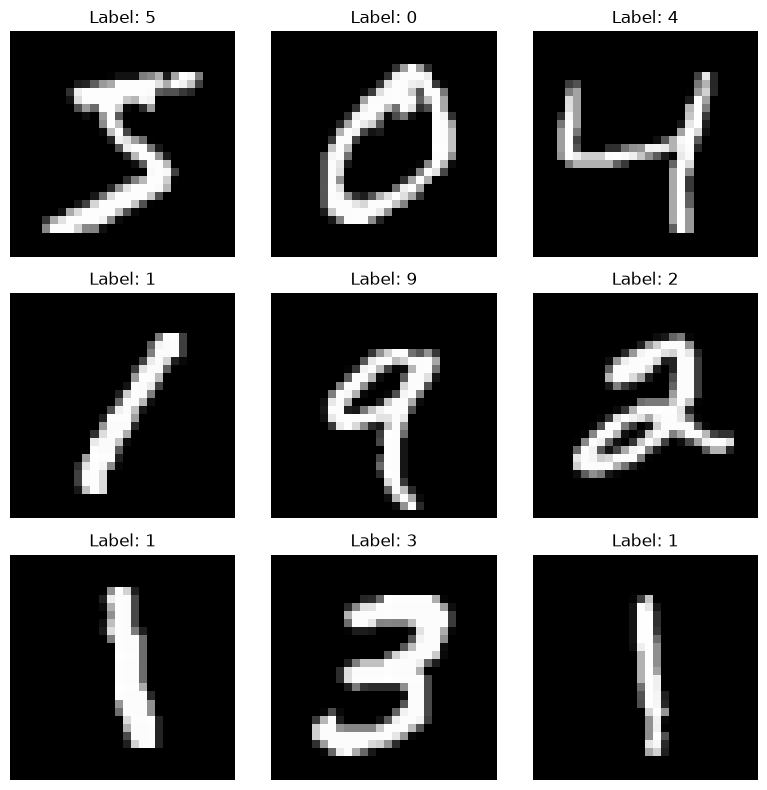

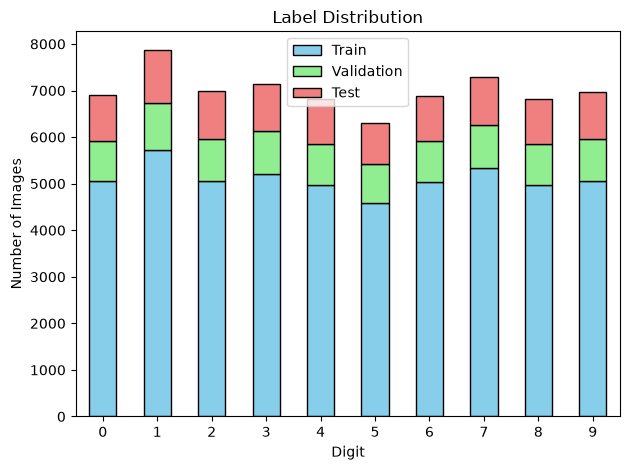

Epoch: 1/25 | Train Loss: 0.1256 | Train Accuracy: 0.9610
Validation Loss: 0.0566 | Validation Accuracy: 0.9832
Epoch: 2/25 | Train Loss: 0.0404 | Train Accuracy: 0.9879
Validation Loss: 0.0491 | Validation Accuracy: 0.9858
Epoch: 3/25 | Train Loss: 0.0257 | Train Accuracy: 0.9919
Validation Loss: 0.0397 | Validation Accuracy: 0.9884
Epoch: 4/25 | Train Loss: 0.0201 | Train Accuracy: 0.9936
Validation Loss: 0.0400 | Validation Accuracy: 0.9882
Epoch: 5/25 | Train Loss: 0.0126 | Train Accuracy: 0.9961
Validation Loss: 0.0461 | Validation Accuracy: 0.9906
Epoch: 6/25 | Train Loss: 0.0117 | Train Accuracy: 0.9963
Validation Loss: 0.0419 | Validation Accuracy: 0.9889
Epoch: 7/25 | Train Loss: 0.0106 | Train Accuracy: 0.9962
Validation Loss: 0.0371 | Validation Accuracy: 0.9904
Epoch: 8/25 | Train Loss: 0.0085 | Train Accuracy: 0.9975
Validation Loss: 0.0352 | Validation Accuracy: 0.9913
Epoch: 9/25 | Train Loss: 0.0073 | Train Accuracy: 0.9976
Validation Loss: 0.0462 | Validation Accuracy:

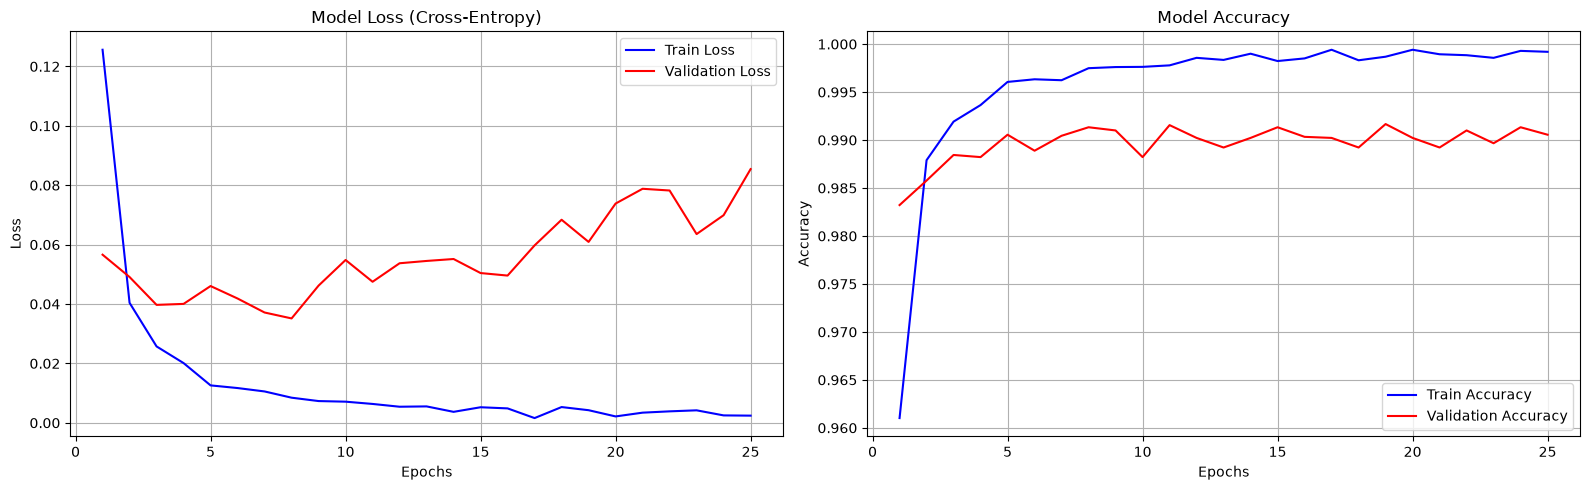

Accuracy: 0.9921
Precision: 0.9922
Recall: 0.9920
F1 score: 0.9921
Confusion Matrix:
[[ 977    0    0    0    1    0    1    1    0    0]
 [   0 1135    0    0    0    0    0    0    0    0]
 [   3    5 1018    1    0    0    0    5    0    0]
 [   0    0    0 1007    0    2    0    1    0    0]
 [   0    0    0    0  975    0    2    2    0    3]
 [   0    0    1    3    0  887    1    0    0    0]
 [   1    3    0    0    1    1  952    0    0    0]
 [   0    2    3    0    0    1    0 1021    0    1]
 [   4    1    1    2    0    1    0    1  962    2]
 [   0    0    0    0    8    5    0    8    1  987]]


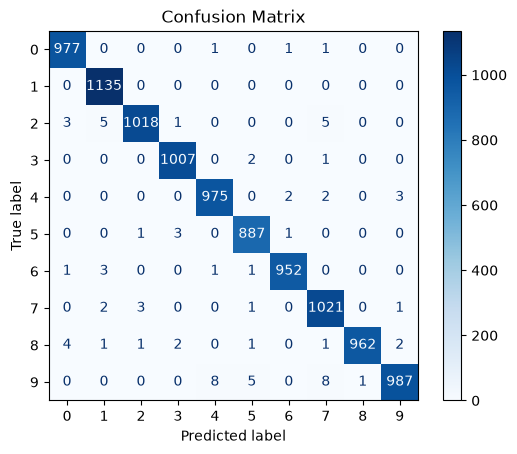

In [12]:
if __name__ == '__main__':
    model, history, confusion_matrix = main()